Gaussian process regressor, kernel density estimation, Radial basis function, MCMC, Bayes information criterion

In [83]:
import numpy as np
import matplotlib.pyplot as plt

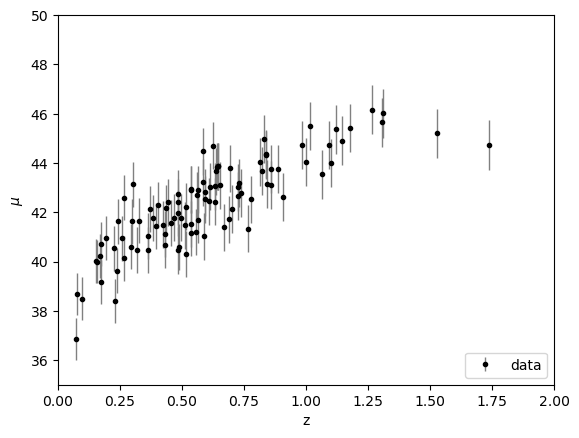

In [84]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [85]:
x_sample = np.reshape(z_sample, [100, 1])
y_sample = mu_sample
x = np.reshape(np.linspace(0, 2, 100), [100, 1])        #how many gaussians
y_err = dmu

In [86]:
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
        
kernel1 = 1.0 * RBF(1.0)
gp = GaussianProcessRegressor(kernel=kernel1, alpha=y_err**2)
gp.fit(x_sample, y_sample)
y_fit, y_std= gp.predict(x, return_std=True)

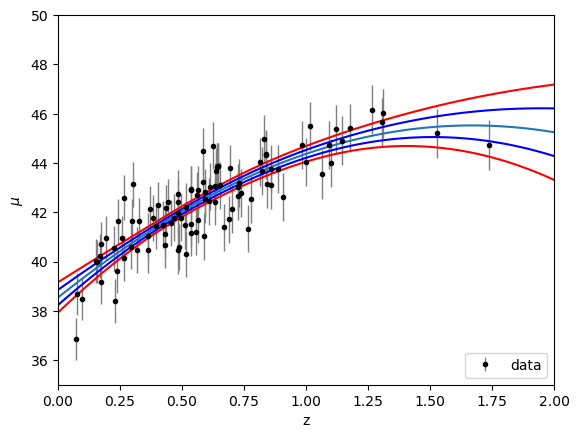

In [87]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')

plt.plot(x, y_fit)
plt.plot(x, y_fit + y_std, c="blue")
plt.plot(x, y_fit - y_std, c="blue")
plt.plot(x, y_fit + 2*y_std, c="red")
plt.plot(x, y_fit - 2*y_std, c="red")

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [88]:
from sklearn.model_selection import GridSearchCV            #from W14
from sklearn.neighbors import KernelDensity

bwrange = np.linspace(0.01, 1.0, 40)
#print(bwrange)
K = 5
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K)
grid.fit(x_sample)
h_opt = grid.best_params_['bandwidth']
print(h_opt)

0.13692307692307693


Text(0.5, 1.0, 'pdf')

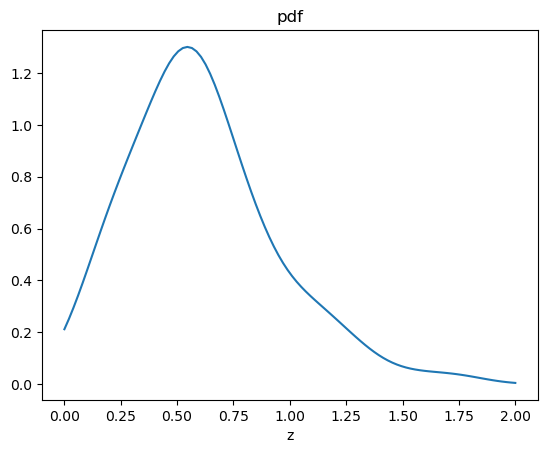

In [89]:
kde_skl = KernelDensity(bandwidth = h_opt)
kde_skl.fit(x_sample)
pdf = np.exp(kde_skl.score_samples(x))

plt.plot(x, pdf)
plt.xlabel("z")
plt.title("pdf")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


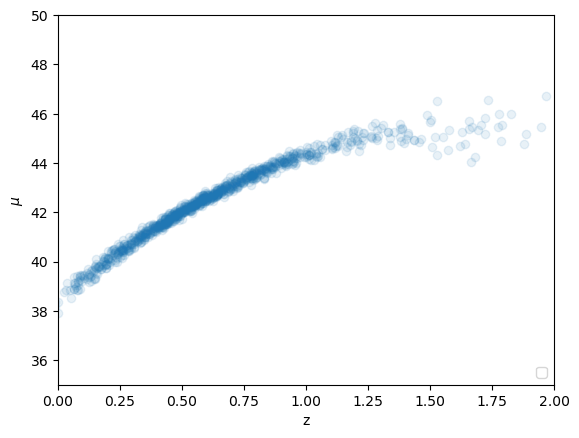

In [90]:
N = 1000
x_sample_generated = kde_skl.sample(N)        #x sample sampled from the pdf of my GPR fit

y_gpr=[]
for z in x_sample_generated.flatten():    
    y_fit, y_std = gp.predict([[z]], return_std=True)
    y_gpr.append(np.random.normal(y_fit, y_std))

plt.scatter(x_sample_generated, y_gpr, alpha=0.1)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);


In [91]:
from scipy.integrate import quad
import scipy.stats as scistats

def distance_modulus(params, z):
    OM, H0 = params
    ODE = 1 - OM        #assume only 2 contributions
    pc = 1e-6           #in megaparsec
    c = 3e5             #km/s
  
    return np.array([5*np.log10((c/H0)/(10*pc)*(1+X)*quad(lambda x: 1/(OM*(1+x)**3 + ODE)**0.5, 0, X)[0]) for X in z])
#non è 1+z^3 ma (1+z)^3

**my way**

In [92]:
#REMEMBER
#plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
#x_sample = np.reshape(z_sample, [100, 1])      is the z
#y_sample = mu_sample                           is the distance modulus
#y_err = dmu                                    is the distance modulus error                                            

#data = np.stack((z_sample, y_sample, y_err), axis=1)

#from W11
#def Likelihood(params, data, mod=distance_modulus):
#    x, y, y_std = np.transpose(data)
#    y_model = mod(params, x)
#    if params[1]<0: return 0
#    return np.prod(np.exp(-(y-y_model)**2 /2 /y_std**2))

#def Prior(params):
#    H0, OM = params
#    if 50 < H0 < 100 and 0.1 < OM < 1:
#        return 1.0/10
#    return 0


#def myPosterior(params, data, mod=distance_modulus):
#    return Likelihood(params, data, mod) * Prior(params)

# emcee wants ln of posterior pdf
#def myLogPosterior(params, data, mod=distance_modulus):
#    a = np.log(myPosterior(params, data, mod))
#    if np.isnan(a): return -np.inf
#    return a

In [93]:
#REMEMBER
#plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
#x_sample = np.reshape(z_sample, [100, 1])      is the z
#y_sample = mu_sample                           is the distance modulus
#y_err = dmu                                    is the distance modulus error                                            

data = np.stack((z_sample, y_sample, y_err), axis=1)

x, y, y_std = np.transpose(data)


def LogLikelihood(params, mod=distance_modulus):

    if params[0]<0: return -np.inf
    y_model = mod(params, x)

    #a = np.sum(np.log(1/np.sqrt(2*np.pi*y_std**2) * np.exp(-1/2*((y-y_model)/y_std)**2)))
    #print(a)
    #return a
    return np.sum(-(y-y_model)**2 /2 /y_std**2)    #old


def LogPrior(params):
    OM, H0 = params
    if 50 < H0 < 100 and 0.1 < OM < 1:
        return 0
    return -np.inf


def LogPosterior(params, mod=distance_modulus):
    return LogLikelihood(params, mod=distance_modulus) + LogPrior(params)

In [94]:
import emcee
import corner

ndim = 2
nwalkers = 5                #12 minutes not finished with 20 walkers, I'll try 5 like the solution says (instead of 20 from W11)
                            #I also changed the model to use list comprehension instead of append
nsteps = int(1e4)

starting_guesses = np.array([0.5,80]) + 1e-1* np.random.randn(nwalkers, ndim)


In [95]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior)
sampler.run_mcmc(starting_guesses, nsteps);
#10 minutes

In [96]:
samples = sampler.get_chain()
samples.shape

(10000, 5, 2)

In [97]:
tau = sampler.get_autocorr_time()
print(tau)

[56.0580455  57.28028353]


In [98]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)
print(flat_samples.shape)

(860, 2)


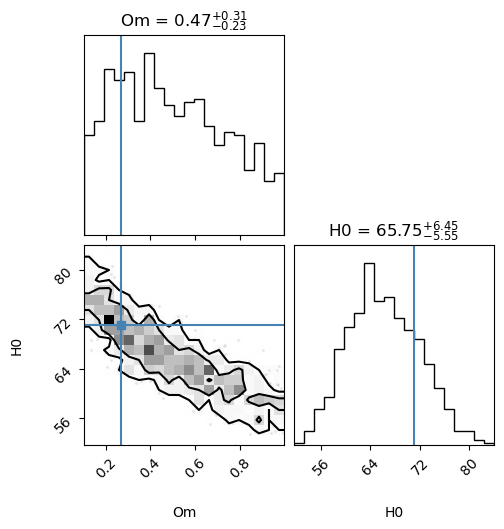

In [99]:
fig = corner.corner(
    flat_samples, labels=["Om","H0"], levels=[0.68,0.95], show_titles=True, truths=[0.27,71]
);

In [100]:
zlin = np.linspace(0,2,100)[1:]

(35.0, 50.0)

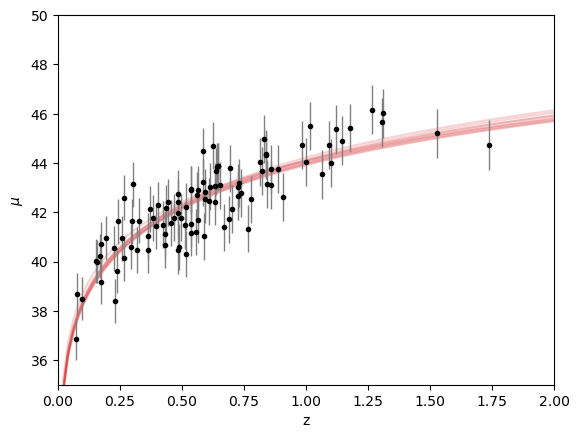

In [101]:
for Om,H0, in flat_samples[::100]:
    plt.plot(zlin, distance_modulus((Om, H0), zlin),c='C3',alpha=0.2)
    
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)

In [102]:
best_idx = np.argmax(sampler.get_log_prob(discard=3*int(max(tau)), thin=int(max(tau)), flat=True))
best_params = flat_samples[best_idx]
max_log_likelihood = LogLikelihood(best_params)
print(max_log_likelihood)
BIC = -2 * max_log_likelihood + ndim * np.log(len(z_sample))

-46.38531303462974


In [103]:
print(BIC)

101.98096644123567


In [104]:
print(len(flat_samples))

860


In [105]:
marg = []
for i in flat_samples:
    if i[0] > 0.9:
        marg.append(i[1])

print(len(marg))
marg = np.array(marg)

49


In [106]:
bwrange = np.linspace(0.01, 10, 400)
#print(bwrange)
K = 5
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K)
grid.fit(marg.reshape(-1, 1))
h_opt = grid.best_params_['bandwidth']
print(h_opt)

1.4621804511278196


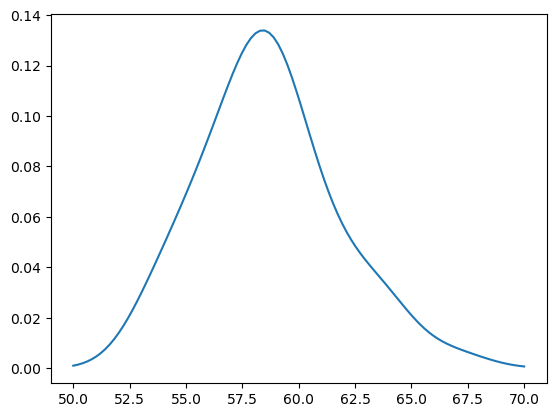

In [107]:
kde_skl = KernelDensity(bandwidth = h_opt)
kde_skl.fit(marg.reshape(-1, 1))
pdf = np.exp(kde_skl.score_samples(np.linspace(50, 70, 100).reshape(-1, 1)))

plt.plot(np.linspace(50, 70, 100), pdf)

OM = 1

In [108]:
def LogLikelihood(params, mod=distance_modulus):

    H0 = float(params)
    Om = 1

    y_model = mod((Om, H0), x)

    #a = np.sum(np.log(1/np.sqrt(2*np.pi*y_std**2) * np.exp(-1/2*((y-y_model)/y_std)**2)))
    #print(a)
    #return a
    return np.sum(-(y-y_model)**2 /2 /y_std**2)    #old


def LogPrior(params):
    H0 = params
    if 50 < H0 < 100:
        return 0
    return -np.inf


def LogPosterior(params, mod=distance_modulus):
    return LogLikelihood(params, mod=distance_modulus) + LogPrior(params)

In [109]:
ndim = 1
nwalkers = 5

nsteps = int(1e4)

starting_guesses = np.array([55]) + 1e-1* np.random.randn(nwalkers, ndim)

In [110]:
sampler_1 = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior)
sampler_1.run_mcmc(starting_guesses, nsteps);

In [111]:
samples = sampler_1.get_chain()
samples.shape

(10000, 5, 1)

In [112]:
tau = sampler_1.get_autocorr_time()
print(tau)

[29.6860809]


In [113]:
flat_samples = sampler_1.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)
print(flat_samples.shape)

(1705, 1)


In [114]:
zlin = np.linspace(0,2,100)[1:]

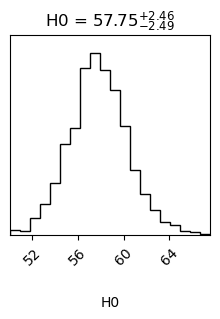

In [115]:
fig = corner.corner(
    flat_samples, labels=["H0"], levels=[0.68,0.95], show_titles=True, truths=[71]
);

(35.0, 50.0)

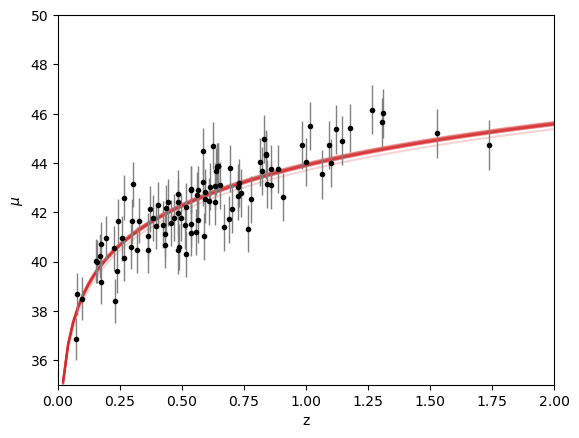

In [116]:
for H0 in flat_samples[::100]:
    plt.plot(zlin, distance_modulus((1, H0), zlin),c='C3',alpha=0.2)
    
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)

emcee doesn't have the bayes factor

In [117]:

best_idx = np.argmax(sampler_1.get_log_prob(discard=3*int(max(tau)), thin=int(max(tau)), flat=True))
best_params = flat_samples[best_idx]
max_log_likelihood = LogLikelihood(best_params)
print(max_log_likelihood)
BIC = -2 * max_log_likelihood + ndim * np.log(len(z_sample))

-47.10216525561047


In [118]:
print(BIC)

98.80950069720903


I know that I should use the Bayes factor because the models have a nested parameter

In [119]:
#I don't know if this is useful
print(sampler.flatlnprobability[-1]/sampler_1.flatlnprobability[-1])

0.9566152833201088


Note on BIC, it favors simpler models

Savage Dickey  I don't think I need to compute the prior because it's flat

In [122]:
bwrange = np.linspace(0.01, 10, 400)
#print(bwrange)
K = 5
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K)
grid.fit(flat_samples)
h_opt = grid.best_params_['bandwidth']
print(h_opt)

0.7110526315789474


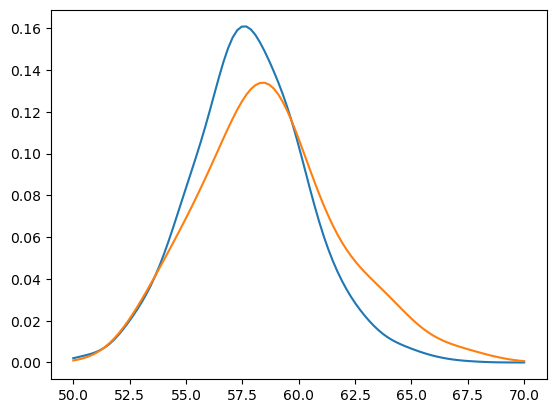

In [125]:
kde_skl = KernelDensity(bandwidth = h_opt)
kde_skl.fit(flat_samples)
pdf2 = np.exp(kde_skl.score_samples(np.linspace(50, 70, 100).reshape(-1, 1)))

plt.plot(np.linspace(50, 70, 100), pdf2, label="simple_model")
plt.plot(np.linspace(50, 70, 100), pdf, label="broad model")